In [80]:
import os
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [81]:
BASE_PATH = 'dataset'
MODELS = os.path.join(BASE_PATH, 'models')
OUTPUT_PIPELINE = os.path.join(BASE_PATH, 'output_pipeline')
DATASET = os.path.join(BASE_PATH, 'dataset_produksi_padi.csv')      
    
os.makedirs(os.path.join(OUTPUT_PIPELINE, 'k-means'), exist_ok=True)

In [82]:
df = pd.read_csv(DATASET)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2545 entries, 0 to 2544
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   kabupaten           2545 non-null   object 
 1   luas_panen          2545 non-null   float64
 2   produktivitas       2545 non-null   float64
 3   produksi            2545 non-null   float64
 4   tahun               2545 non-null   int64  
 5   provinsi            2545 non-null   object 
 6   curah_hujan_rataan  2545 non-null   float64
 7   curah_hujan_total   2545 non-null   float64
 8   suhu_rataan         2545 non-null   float64
 9   suhu_maksimum       2545 non-null   float64
 10  suhu_minimum        2545 non-null   float64
 11  kelembapan_rataan   2545 non-null   float64
dtypes: float64(9), int64(1), object(2)
memory usage: 238.7+ KB


In [84]:
df_kalimantan = df[df['provinsi'].str.contains('Kalimantan', case=False, na=False)].copy()
print(f"Total baris data Kalimantan: {df_kalimantan.shape[0]}")

Total baris data Kalimantan: 452


In [85]:
df_kabupaten = df_kalimantan.groupby('kabupaten').agg({
    'produktivitas': 'mean',
    'luas_panen': 'mean',
    'curah_hujan_total': 'mean',
    'suhu_rataan': 'mean'
}).reset_index()

In [86]:
fitur_cluster = ['produktivitas', 'luas_panen', 'curah_hujan_total', 'suhu_rataan']
X_cluster = df_kabupaten[fitur_cluster]

scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X_cluster)

In [87]:
df_kabupaten.head()

,kabupaten,produktivitas,luas_panen,curah_hujan_total,suhu_rataan
0,balangan,36.767500,5501.94000,2901.591250,25.070282
1,balikpapan,33.754286,68.07000,2515.055714,26.458454
2,banjar,46.646875,26563.78750,2994.093750,26.790369
3,banjarbaru,31.878750,1092.02875,2994.093750,26.790369
4,banjarmasin,40.030000,2259.78375,3428.555000,27.878527


In [88]:
# Mencari jumlah klaster (K) optimal
wcss = []
silhouette_scores = []
K_range = range(2, 11) # Mencoba dari 2 hingga 10 klaster

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

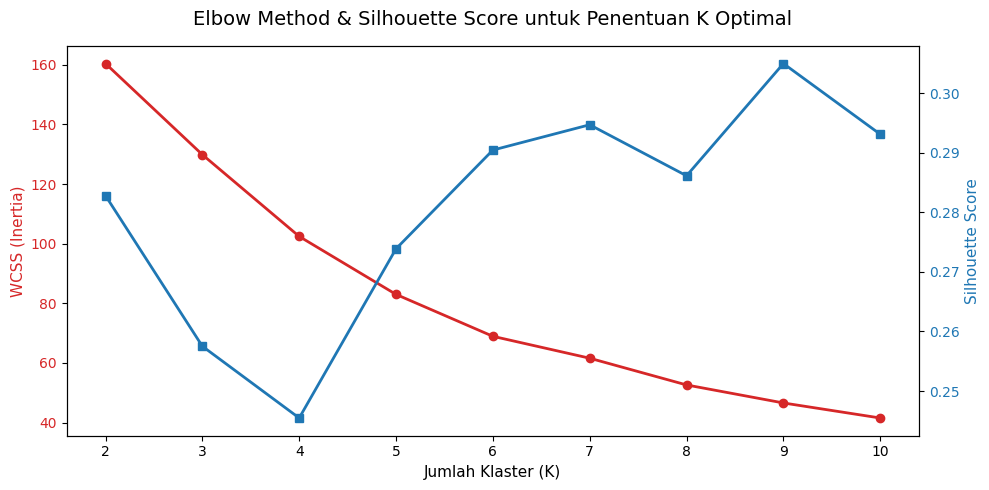

In [89]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Elbow Method (WCSS)
color = 'tab:red'
ax1.set_xlabel('Jumlah Klaster (K)', fontsize=11)
ax1.set_ylabel('WCSS (Inertia)', color=color, fontsize=11)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Plot Silhouette Score di sumbu Y yang sama namun berlawanan
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=11)
ax2.plot(K_range, silhouette_scores, marker='s', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method & Silhouette Score untuk Penentuan K Optimal', fontsize=14, pad=15)
fig.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [90]:
JUMLAH_KLASTER = 3

kmeans_model = KMeans(n_clusters=JUMLAH_KLASTER, random_state=42, n_init=10)
df_kabupaten['Cluster'] = kmeans_model.fit_predict(X_scaled)

mapping_label = {
    0: 'Unggul (High Yield)',
    1: 'Berkembang (Developing)',
    2: 'Rawan (At-Risk)'
}

profil_klaster = df_kabupaten.groupby('Cluster').agg({
    'kabupaten': 'count', # Menghitung jumlah kabupaten di klaster ini
    'produktivitas': 'mean',
    'luas_panen': 'mean',
    'curah_hujan_total': 'mean',
    'suhu_rataan': 'mean'
}).rename(columns={'kabupaten': 'jumlah_kabupaten'}).round(2)

# Terapkan ke dataframe
df_kabupaten['label_klaster'] = df_kabupaten['Cluster'].map(mapping_label)
display(df_kabupaten)

,kabupaten,produktivitas,luas_panen,curah_hujan_total,suhu_rataan,Cluster,label_klaster
0,balangan,36.767500,5501.940000,2901.591250,25.070282,0,Unggul (High Yield)
1,balikpapan,33.754286,68.070000,2515.055714,26.458454,0,Unggul (High Yield)
2,banjar,46.646875,26563.787500,2994.093750,26.790369,2,Rawan (At-Risk)
3,banjarbaru,31.878750,1092.028750,2994.093750,26.790369,1,Berkembang (Developing)
4,banjarmasin,40.030000,2259.783750,3428.555000,27.878527,2,Rawan (At-Risk)
5,barito kuala,34.977500,69764.493750,3078.885000,26.883045,2,Rawan (At-Risk)
6,barito selatan,31.546250,2318.295000,3082.608750,26.275400,1,Berkembang (Developing)
7,barito timur,33.951250,5321.863750,3109.281250,25.382385,1,Berkembang (Developing)
8,barito utara,26.160000,3091.693750,3204.801250,25.932031,1,Berkembang (Developing)
9,bengkayang,30.075000,11553.197500,3655.817500,26.264616,1,Berkembang (Developing)


In [91]:
joblib.dump(kmeans_model, os.path.join(MODELS, "kmeans_segmentation_kalimantan.pkl"))

['dataset/models/kmeans_segmentation_kalimantan.pkl']

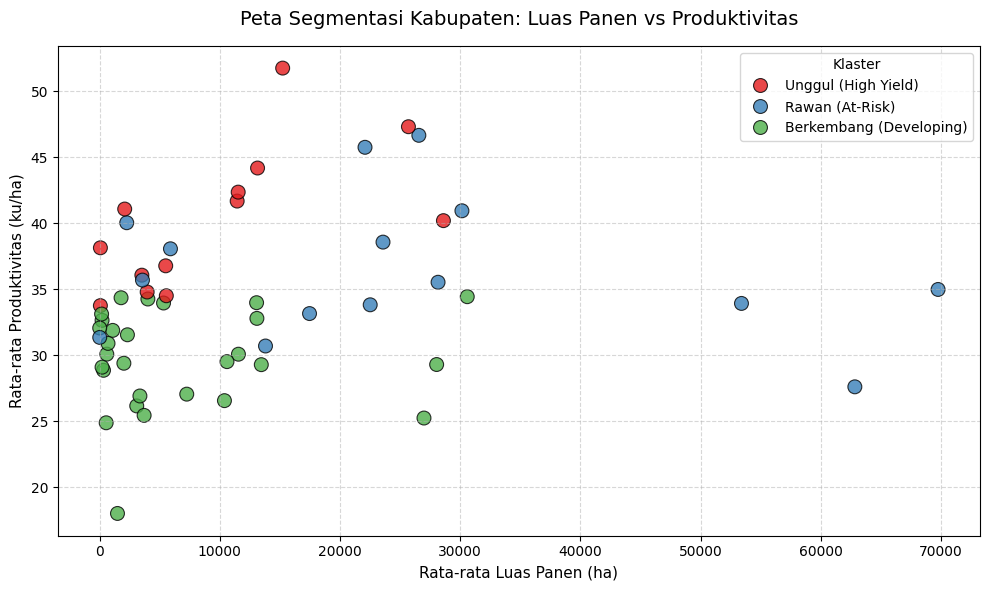

Contoh Kabupaten di Klaster Unggul (High Yield): balangan, balikpapan, berau, bontang, hulu sungai tengah
Contoh Kabupaten di Klaster Berkembang (Developing): banjarbaru, barito selatan, barito timur, barito utara, bengkayang
Contoh Kabupaten di Klaster Rawan (At-Risk): banjar, banjarmasin, barito kuala, hulu sungai selatan, kapuas


In [92]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_kabupaten, 
    x='luas_panen', 
    y='produktivitas', 
    hue='label_klaster', 
    palette='Set1', 
    s=100, 
    alpha=0.8,
    edgecolor='black'
)

plt.title('Peta Segmentasi Kabupaten: Luas Panen vs Produktivitas', fontsize=14, pad=15)
plt.xlabel('Rata-rata Luas Panen (ha)', fontsize=11)
plt.ylabel('Rata-rata Produktivitas (ku/ha)', fontsize=11)
plt.legend(title='Klaster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PIPELINE, 'k-means/segmentasi_kabupaten.png'), 
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Menampilkan contoh kabupaten di masing-masing klaster
for i in range(JUMLAH_KLASTER):
    contoh_kab = df_kabupaten[df_kabupaten['label_klaster'] == mapping_label[i]]['kabupaten'].head(5).tolist()
    print(f"Contoh Kabupaten di Klaster {mapping_label[i]}: {', '.join(contoh_kab)}")